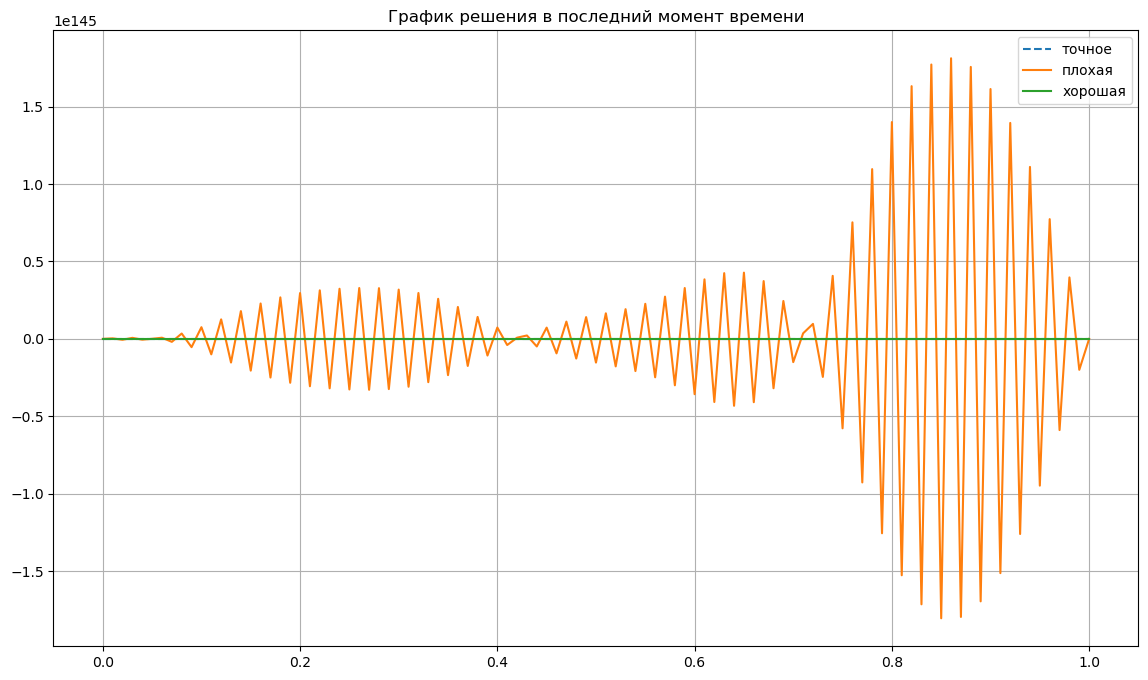

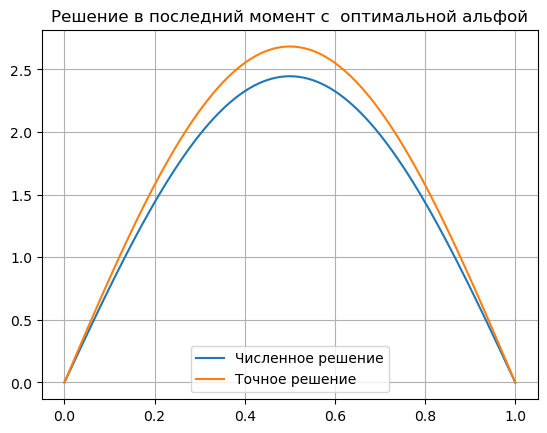

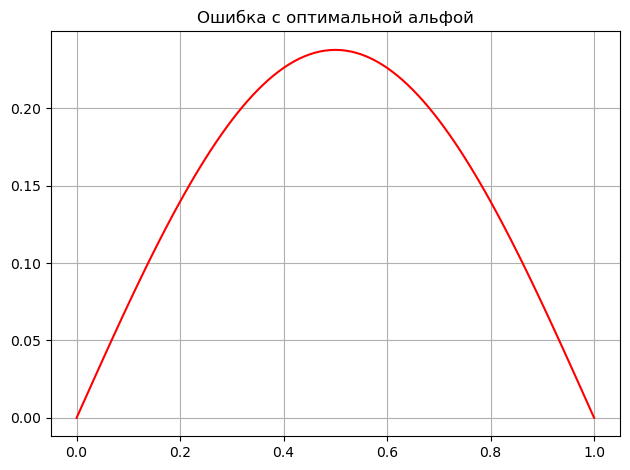

Оптимальная альфа ≈ 1.000e-02
tau = 0.001
Ошибка плохой схемы : 4.65e+146
Ошибка хорошей схемы: 1.51e+01


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded


m, steps = 101, 100
# m, steps = 50, 50
# m, steps = 25, 25

T = 0.1
k, L = 1, 1.0
# alphas = np.logspace(-10, 1, 30)
# alphas = np.linspace(0.01, 100, 30)
# alphas = np.linspace(1e-2, 1, 30)
# alphas = np.linspace(0.00001, 0.1, 30)
# alphas = np.linspace(0.020, 0.025, 30)
alphas = np.linspace(0.000001, 0.01, 200)
# alphas = 1e-2


h = L / (m - 1)
tau = T / steps
x = np.linspace(0, L, m)
x_acc = np.linspace(0,L,100)

# exact = lambda t,a: np.exp(np.pi**2 * k**2 * t/(1+a*np.pi**2 * k**2)) * np.sin(np.pi*k*x)
exact = lambda t,a: np.exp(np.pi**2 * k**2 * t) * np.sin(np.pi*k*x)




def D2(u):
    res = np.zeros_like(u)
    res[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / h**2
    return res


def evolve_bad(u):
    hist = [u.copy()]
    for _ in range(steps):
        u = u -  tau * D2(u)
        u[[0,-1]] = 0
        hist.append(u.copy())
    return np.array(hist)

# def evolve_good(u, alpha):
#     hist = [u.copy()]
#     r = (tau - alpha) / h**2

#     A = np.diag((1 - 2*r)*np.ones(m)) \
#       + np.diag(r*np.ones(m-1),1) \
#       + np.diag(r*np.ones(m-1),-1)
#     A[0,:]=A[-1,:]=0; 
#     A[0,0]=A[-1,-1]=1

#     for _ in range(steps):
#         b = u - alpha * D2(u)
#         b[0]=b[-1]=0
#         u_new = np.linalg.solve(A, b)
#         u = u_new
#         hist.append(u.copy())
#     return np.array(hist)


def evolve_good(u, alpha):

    m = len(u)
    hist = [u.copy()]
    
    a_diag = 1 + 2 * alpha / h**2
    a_off = -alpha / h**2
    
    gamma = (tau + alpha) / h**2
    
    A = np.diag(a_diag * np.ones(m)) \
      + np.diag(a_off * np.ones(m-1), 1) \
      + np.diag(a_off * np.ones(m-1), -1)
    
    A[0, :] = A[-1, :] = 0
    A[0, 0] = A[-1, -1] = 1

    for _ in range(steps):
        b = np.zeros(m)
        b[1:-1] = (1 + 2*gamma) * u[1:-1] - gamma * u[2:] - gamma * u[:-2]
        b[0] = 0
        b[-1] = 0
        u_new = np.linalg.solve(A, b)
        u = u_new
        hist.append(u.copy())
    return np.array(hist)

def error(u, a):
    # return (np.mean((u - exact(T, a))**2))
    return (np.sum(np.abs((u - exact(T, a)))))



u0 = np.sin(np.pi * k * x)
# u0 = np.sin(np.pi * k * x) + np.random.normal(0, 0.01, m)

bad = evolve_bad(u0.copy())

# errs = []
# for a in alphas:
#     err = error(evolve_good(u0.copy(), a)[-1],a)
#     print(f'alpha = {a}, err = {err}')
#     errs.append(err)
# best_alpha = alphas[np.argmin(errs)]
best_alpha = 1e-2

good = evolve_good(u0.copy(), best_alpha)

# t = np.linspace(0, T, steps+1)


plt.figure(figsize=(14,8))
plt.plot(x, exact(T,best_alpha), '--', label='точное')
plt.plot(x, bad[-1], label='плохая')
plt.plot(x, good[-1], label='хорошая')
plt.title("График решения в последний момент времени")
plt.legend(); plt.grid()
plt.show()


# # plt.semilogx(alphas, errs, 'o-')
# plt.plot(alphas, errs, 'o-')
# # plt.axvline(tau, color='b', ls='--')
# plt.axvline(best_alpha, color='r', ls='--')
# plt.title(f"Подбор оптимальной альфы"); plt.grid()
# plt.show()



# plt.plot(x, good[-1]-exact(T,best_alpha), 'r')
plt.plot(x, good[-1],label='Численное решение')
# for a in alphas:
#     plt.plot(x, evolve_good(u0.copy(), a)[-1],label=f'Численное решение при a = {a}')
plt.plot(x, exact(T,best_alpha), label='Точное решение')
plt.legend()
plt.title("Решение в последний момент с  оптимальной альфой"); plt.grid()
plt.show()

plt.plot(x, np.abs(good[-1]-exact(T,best_alpha)), 'r')
plt.title("Ошибка с оптимальной альфой"); plt.grid()
plt.tight_layout()
plt.show()

print(f"Оптимальная альфа ≈ {best_alpha:.3e}")
print(f'tau = {tau}')
print(f"Ошибка плохой схемы : {error(bad[-1],best_alpha):.2e}")
print(f"Ошибка хорошей схемы: {error(good[-1],best_alpha):.2e}")
# print(exact(T,best_alpha))
# print()
# print(good[-1])
# print()
# print(exact(T,best_alpha) - good[-1])

(np.float64(2.6830667234590573), np.float64(2.4454380059763903))

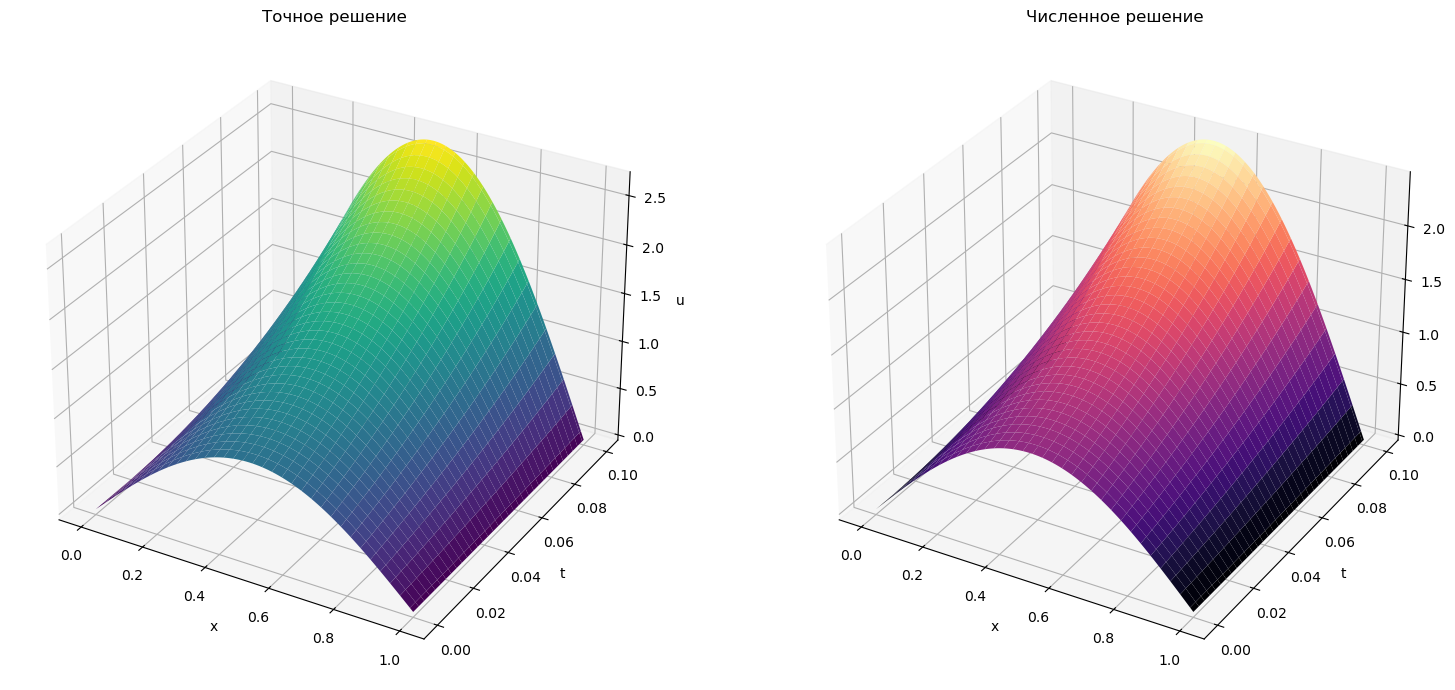

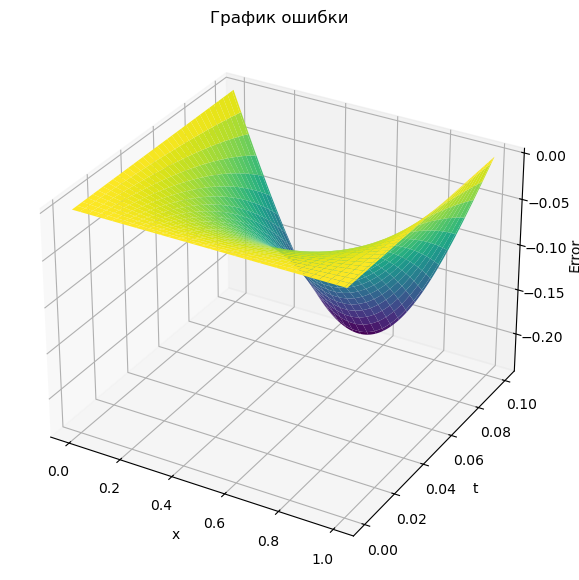

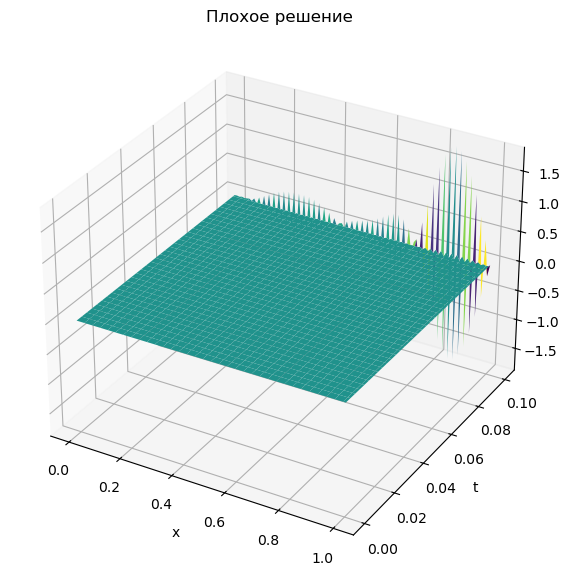

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded
from mpl_toolkits.mplot3d import Axes3D 

m, steps = 101, 100
# m, steps = 40, 40

T, k, L = 0.1, 1, 1.0
h = L / (m - 1)
tau = T / steps
x = np.linspace(0, L, m)
t_axis = np.linspace(0, T, steps + 1) 

exact = lambda t, a: np.exp(np.pi**2 * k**2 * t) * np.sin(np.pi * k * x)
# exact = lambda t,a: np.exp(np.pi**2 * k**2 * t/(1+a*np.pi**2 * k**2)) * np.sin(np.pi*k*x)


def D2(u):
    res = np.zeros_like(u)
    res[1:-1] = (u[2:] - 2*u[1:-1] + u[:-2]) / h**2
    return res


def evolve_bad(u):
    hist = [u.copy()]
    for _ in range(steps):
        u = u -  tau * D2(u)
        u[[0,-1]] = 0
        hist.append(u.copy())
    return np.array(hist)



def evolve_good(u, alpha):
    m = len(u)
    hist = [u.copy()]
    a_diag = 1 + 2 * alpha / h**2
    a_off = -alpha / h**2
    gamma = (tau + alpha) / h**2
    A = np.diag(a_diag * np.ones(m)) \
      + np.diag(a_off * np.ones(m-1), 1) \
      + np.diag(a_off * np.ones(m-1), -1)
    
    A[0, :] = A[-1, :] = 0
    A[0, 0] = A[-1, -1] = 1
    
    for _ in range(steps):
        b = np.zeros(m)
        b[1:-1] = (1 + 2*gamma) * u[1:-1] - gamma * u[2:] - gamma * u[:-2]
        u = np.linalg.solve(A, b)
        hist.append(u.copy())
    return np.array(hist)






best_alpha = 1e-2
u0 = np.sin(np.pi * k * x)
bad_numerical_sol = evolve_bad(u0.copy())
numerical_sol = evolve_good(u0.copy(), best_alpha)









X, T_grid = np.meshgrid(x, t_axis)
exact_sol = np.array([exact(ti, best_alpha) for ti in t_axis])

fig = plt.figure(figsize=(16, 7))
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(X, T_grid, exact_sol, cmap='viridis')
ax1.set_title('Точное решение')
ax1.set_xlabel('x'); ax1.set_ylabel('t'); ax1.set_zlabel('u')

ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(X, T_grid, numerical_sol, cmap='magma')
ax2.set_title('Численное решение')
ax2.set_xlabel('x'); ax2.set_ylabel('t'); ax2.set_zlabel('u')

plt.tight_layout()
plt.show()

fig_err = plt.figure(figsize=(10, 7))
ax3 = fig_err.add_subplot(1, 1, 1, projection='3d')
surf = ax3.plot_surface(X, T_grid, numerical_sol - exact_sol, cmap='viridis', edgecolor='none')
ax3.set_title('График ошибки')
ax3.set_xlabel('x')
ax3.set_ylabel('t')
ax3.set_zlabel('Error')
plt.show()

fig_err = plt.figure(figsize=(10, 7))
# scatter = ax.plot_wireframe(X, T_grid, diff, color='darkblue', linestyle = '--', linewidth = 0.5, alpha=0.7)

ax4 = fig_err.add_subplot(1, 1, 1, projection='3d')
surf = ax4.plot_surface(X, T_grid, bad_numerical_sol, cmap='viridis', edgecolor='none')
ax4.set_title('Плохое решение')
ax4.set_xlabel('x')
ax4.set_ylabel('t')
ax4.set_zlabel('u')
plt.show()

# print(f"Оптимальная альфа: {best_alpha}")